# 8 기하학 처리
영상 처리에서 기하학 처리는 영상 내에 있는 기하학적 대상의 공간적 배치를 변경하는 과정이다. 이 변환은 크게 회전(Rotation), 크기 변경(Scaling), 평행 이동(Translation) 등이 있고 이 세가지 변환을 RST 변환이라고 한다.  

## 8.1 사상
기하학적 처리의 기본은 화소들의 배치를 변경하는 것이다. 그래서 입력 영상의 새롭게 배치될 해당 목적 영상의 좌표를 찾아서 화소 값을 옮기는 과정이다.  
* 순방향 사상  
입력 영상의 좌표를 중심으로 목적 영상의 좌표를 계산하여 화소의 위치를 변환하는 방식이다. 이 방식은 일반적으로 입력과 목적이 크기가 같을 때 유용하게 사용되고 크기가 다르면 홀이나 오버랩의 문제가 발생한다.  
    * 홀: 입력 영상의 좌표들로 목적 영상의 좌표를 만드는 과정에서 사상 되지 않은 원소, 확대나 회전시 발생
    * 오버랩: 입력의 여러 화소들이 목적의 한 화소로 사상되는 것, 축소시 발생
* 역방향 사상  
순방향의 반대 방향 사상이다. 홀이나 오버랩은 발생하지 않지만 입력 영상의 한 화소를 목적 영상의 여러 화소에서 사용하면 결과 영상의 품질이 떨어진다. 이러한 문제를 보간법이다.  

## 8.2 크기 변경 (확대/축소)
크기 변경은 입력 영상의 가로, 세로로 크기를 변경해서 목적 영상을 만드는 방법  
크기 변경 하는 방법은 비율을 이용해서 수행할 수 있다. 비율을 지정하여 입력 영상의 좌표에 스칼라 곱하면 계산할 수 있다. 그리고 목적 영상의 크기를 지정해서 변경할 수 있다. 입력영상/목적영상 크리고 비율을 계산하여 전자처럼 곱하여 계산한다.


In [8]:
import numpy as np, cv2, time
import matplotlib.pyplot as plt

In [6]:
def scaling(img, size):
    dst = np.zeros(size[::-1], img.dtype)
    ratioY, ratioX = np.divide(size[::-1], img.shape[:2])
    y = np.arange(0, img.shape[0], 1)
    x = np.arange(0, img.shape[1], 1)
    y, x = np.meshgrid(y, x)
    i, j = np.int32(y * ratioY), np.int32(x * ratioX)
    dst[i, j] = img[y, x]
    return dst

def scaling2(img, size):
    dst = np.zeros(size[::-1], img.dtype)
    ratioY, ratioX = np.divide(size[::-1], img.shape[:2])
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            i, j = int(y * ratioY), int(x * ratioX)
            dst[i, j] = img[y, x]
    
    return dst

def time_check(func, img, size, title):
    start_time = time.perf_counter()
    ret_img = func(img, size)
    elapsed = (time.perf_counter() - start_time) * 1000
    print(title, "elapsed time: %0.2f ms" % elapsed)
    return ret_img

point mat elapsed time: 273.56 ms
loop elapsed time: 3128.78 ms


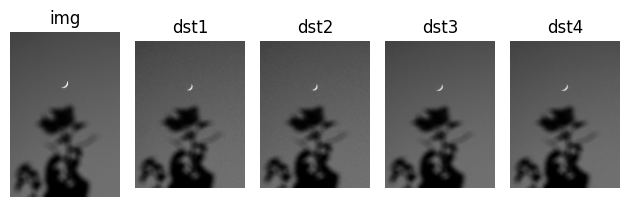

In [13]:
img = cv2.imread("../images/moon.jpg", cv2.IMREAD_GRAYSCALE)

dst1 = scaling(img, (150, 200))
dst2 = scaling2(img, (150, 200))
dst3 = time_check(scaling, img, (300, 400), "point mat")
dst4 = time_check(scaling2, img, (300, 400), "loop")

titles = ['img', 'dst1', 'dst2', 'dst3', 'dst4']
fig, axs = plt.subplots(nrows=1, ncols=5)

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8.3 보간
순방향 사상으로 확대하면 홀이 많이 발생하게 된다. 이러한 문제는 역방향 사상을 통해서 홀의 화소들을 입력 영상에서 찾아 목적 영상의 화소에 대입함으로써 목적 영상의 화질을 유지할 수 있다. 그리고 오버랩되지 않게 화소들을 배치하여 목적영상을 만드는 기법을 보간법이라고 한다.

## 8.3.1 최근접 이웃 보간법
홀